# Complaint Analysis using Amazon Bedrock

## Business Understanding

The objective of this notebook is to automate the analysis of customer complaints submitted to the HP support platform.

The system aims to:

- Summarize customer complaints
- Identify the problem category
- Estimate the urgency level
- Recommend troubleshooting actions
- Improve customer support efficiency

This solution relies on Amazon Bedrock, Retrieval-Augmented Generation (RAG), and HP technical knowledge stored in the knowledge base.

## CRISP-DM Methodology

This experiment follows the CRISP-DM methodology:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling (Prompt Engineering + Amazon Bedrock)
5. Evaluation
6. Deployment

The objective is to evaluate the effectiveness of Generative AI for intelligent complaint analysis.

In [12]:
import pandas as pd

complaints = [
    {
        "product":"HP LaserJet M12",
        "description":"My printer does not turn on anymore. The power LED is blinking."
    },
    {
        "product":"HP Pavilion",
        "description":"The laptop displays a black screen after startup."
    },
    {
        "product":"HP DeskJet",
        "description":"The printer is connected but cannot print any document."
    },
    {
        "product":"HP EliteBook",
        "description":"The WiFi connection keeps disconnecting."
    }
]

df = pd.DataFrame(complaints)

df

,product,description
0,HP LaserJet M12,My printer does not turn on anymore. The power...
1,HP Pavilion,The laptop displays a black screen after startup.
2,HP DeskJet,The printer is connected but cannot print any ...
3,HP EliteBook,The WiFi connection keeps disconnecting.


In [13]:
df["description_length"] = df["description"].apply(len)

df

,product,description,description_length
0,HP LaserJet M12,My printer does not turn on anymore. The power...,63
1,HP Pavilion,The laptop displays a black screen after startup.,49
2,HP DeskJet,The printer is connected but cannot print any ...,55
3,HP EliteBook,The WiFi connection keeps disconnecting.,40


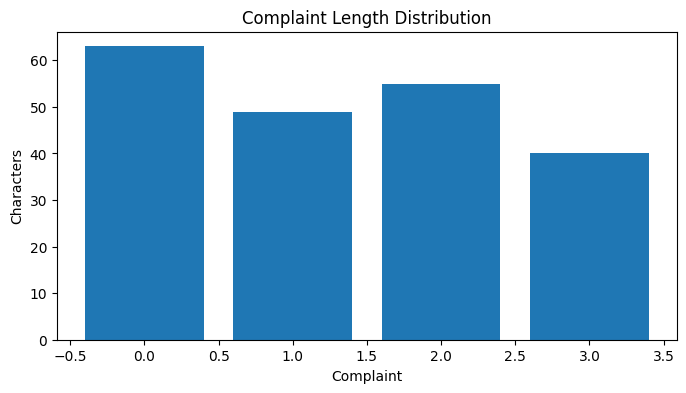

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(df.index, df["description_length"])
plt.title("Complaint Length Distribution")
plt.xlabel("Complaint")
plt.ylabel("Characters")
plt.show()

In [15]:
def create_basic_prompt(description):

    return f"""
    Analyze the following complaint:

    {description}

    Provide a solution.
    """

In [16]:
def create_advanced_prompt(product, description):

    return f"""
    You are an HP support expert.

    Product:
    {product}

    Complaint:
    {description}

    Return:

    1. Problem Summary

    2. Problem Category

    3. Priority Level
       LOW / MEDIUM / HIGH

    4. Probable Cause

    5. Recommended Solution

    6. Recommended Actions
    """

In [17]:
client = boto3.client(
    "bedrock-agent-runtime",
    region_name="us-east-1"
)

In [19]:
for _, row in df.iterrows():

    result = analyze_complaint(
        create_advanced_prompt(
            row["product"],
            row["description"]
        )
    )

    print("="*80)
    print(result)



1. Problem Summary: The HP LaserJet M12 printer is not turning on and the power LED is blinking, indicating a hardware issue.
2. Problem Category: Hardware/Power
3. Priority Level: HIGH
4. Probable Cause: The issue is likely due to a problem with the printer's internal components or power supply.
5. Recommended Solution: To resolve this issue, I recommend the following steps:






1. Check the power cable and ensure it is properly connected to both the printer and the power outlet.
2. Unplug the power cable from the printer, wait 30 seconds, then plug it back in and try turning the printer on again.
3. If the printer still does not turn on, there may be an internal hardware issue. In this case, I recommend contacting HP support for further assistance. The printer is covered by a 1-year manufacturer's warranty, so HP may be able to provide a repair or replacement.






6. Recommended Actions:
- Check the power cable and connection
- Perform a power cycle by unplugging and reconnecti

In [20]:
results = []

for _, row in df.iterrows():

    basic = analyze_complaint(
        create_basic_prompt(
            row["description"]
        )
    )

    advanced = analyze_complaint(
        create_advanced_prompt(
            row["product"],
            row["description"]
        )
    )

    results.append({
        "Complaint": row["product"],
        "Basic Prompt": len(basic),
        "Advanced Prompt": len(advanced)
    })

evaluation_df = pd.DataFrame(results)

evaluation_df

,Complaint,Basic Prompt,Advanced Prompt
0,HP LaserJet M12,794,2985
1,HP Pavilion,743,1869
2,HP DeskJet,948,1483
3,HP EliteBook,904,1882


<Axes: xlabel='Complaint'>

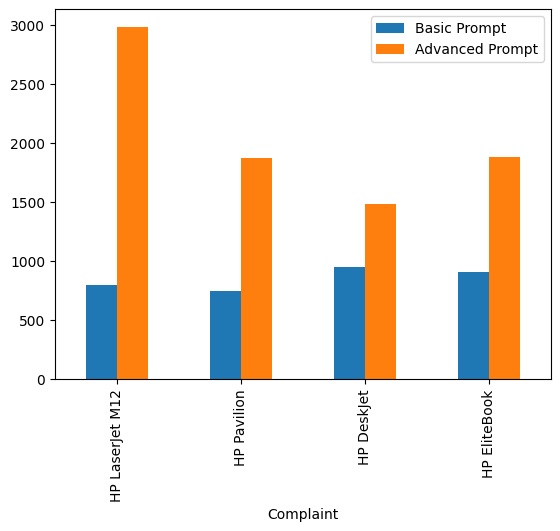

In [21]:
evaluation_df.plot(
    x="Complaint",
    y=["Basic Prompt","Advanced Prompt"],
    kind="bar"
)

In [27]:
sample = df.iloc[0]

basic_response = analyze_complaint(
    create_basic_prompt(
        sample["description"]
    )
)

advanced_response = analyze_complaint(
    create_advanced_prompt(
        sample["product"],
        sample["description"]
    )
)

print("BASIC PROMPT")
print("="*50)
print(basic_response)

print("\n\nADVANCED PROMPT")
print("="*50)
print(advanced_response)

BASIC PROMPT


To troubleshoot the issue with your HP printer not turning on and the power LED blinking, please try the following steps:

1. Check the power cable - Ensure the power cable is firmly connected to both the printer and the power outlet. Try using a different power outlet as well.

2. Reset the printer - Unplug the printer from power for 60 seconds, then plug it back in and try turning it on again.

3. Check for any paper jams - Open the printer and check for any paper or debris that may be causing a jam. Carefully remove any paper or obstructions.

4. Update printer drivers - Download and install the latest printer drivers from the HP support website (support.hp.com/drivers).

If the issue persists after trying these steps, there may be an internal hardware or firmware issue with the printer. In that case, I would recommend contacting HP support for further assistance.





ADVANCED PROMPT
Problem Summary:
The HP LaserJet M12 printer is not turning on, and the power LED is

# Evaluation on Multiple Complaints

To evaluate the robustness of the proposed approach,
multiple complaint scenarios were analyzed using the
advanced prompt and Amazon Bedrock.

In [22]:
evaluation_cases = [
    {
        "product": "HP LaserJet M12",
        "description": "Printer does not turn on anymore."
    },
    {
        "product": "HP Pavilion",
        "description": "Black screen after startup."
    },
    {
        "product": "HP EliteBook",
        "description": "WiFi disconnects repeatedly."
    },
    {
        "product": "HP DeskJet",
        "description": "Printer prints blank pages."
    },
    {
        "product": "HP ProBook",
        "description": "Battery drains very quickly."
    }
]

evaluation_cases

[{'product': 'HP LaserJet M12',
  'description': 'Printer does not turn on anymore.'},
 {'product': 'HP Pavilion', 'description': 'Black screen after startup.'},
 {'product': 'HP EliteBook', 'description': 'WiFi disconnects repeatedly.'},
 {'product': 'HP DeskJet', 'description': 'Printer prints blank pages.'},
 {'product': 'HP ProBook', 'description': 'Battery drains very quickly.'}]

In [23]:
for case in evaluation_cases:

    result = analyze_complaint(
        create_advanced_prompt(
            case["product"],
            case["description"]
        )
    )

    print("="*80)
    print("PRODUCT :", case["product"])
    print("="*80)

    print(result)
    print("\n")

PRODUCT : HP LaserJet M12
Problem Summary:
The HP LaserJet M12 printer is not turning on anymore.

Problem Category:
Power issue - the printer is not receiving power or not able to power on.

Priority Level:
Medium - the printer is not functioning, but this is not an urgent or critical issue.

Probable Cause:
Based on the search results, the probable causes for the HP LaserJet M12 printer not turning on could be:
- Power cable issue - the power cable may be damaged or not properly connected
- Internal hardware failure - there could be an issue with the printer's internal components that is preventing it from powering on

Recommended Solution:
To troubleshoot and resolve the issue of the HP LaserJet M12 printer not turning on, I recommend the following steps:

1. Check the power cable:
   - Ensure the power cable is firmly connected to both the printer and the power outlet.
   - Try a different power cable if available to rule out a cable issue.
   - Check the power outlet to make sure 

# Personalized Complaint Analysis Using Sentiment Context

This experiment evaluates the impact of customer sentiment on the generated response.

The same complaint is analyzed under different emotional contexts:
- Negative
- Neutral
- Positive

In [25]:
def create_sentiment_prompt(product, description, sentiment):

    return f"""
    You are an HP support expert.

    Customer sentiment:
    {sentiment}

    Product:
    {product}

    Complaint:
    {description}

    Adapt your response according to the customer's emotional state.

    Return:
    1. Problem Summary
    2. Priority
    3. Recommended Solution
    """

In [ ]:
complaint = """
My printer does not turn on anymore.
The power LED is blinking.
"""

sentiments = [
    "NEGATIVE",
    "NEUTRAL",
    "POSITIVE"
]

for sentiment in sentiments:

    result = analyze_complaint(
        create_sentiment_prompt(
            "HP LaserJet M12",
            complaint,
            sentiment
        )
    )

    print("=" * 80)
    print("SENTIMENT :", sentiment)
    print("=" * 80)
    print(result)
    print("\n")

SENTIMENT : NEGATIVE
1. Problem Summary:
Your HP LaserJet M12 printer is not turning on and the power LED is blinking, which indicates a technical issue with the printer.

2. Priority:
This is a high priority issue as it prevents you from using the printer. We need to address this problem as soon as possible.

3. Recommended Solution:
To resolve the issue with your HP LaserJet M12 printer not turning on and the blinking power LED, please try the following steps:



1. Check that there are no paper jams or obstructions inside the printer. Open the rear cover and gently remove any paper pieces.
2. Close the cover and try restarting the printer.
3. If the issue persists, the printer may have a hardware or power-related problem. Try unplugging the power cable, waiting 30 seconds, and then plugging it back in to reset the printer.
4. If the printer still does not turn on, the toner cartridge may need to be replaced. The compatible toner cartridge for the M12 is the HP CF206A.
5. If replacin

## Sentiment Analysis Discussion

The generated responses vary according to the emotional context provided in the prompt.

For negative sentiment, the model produces more empathetic and reassuring responses.

For neutral sentiment, the response is concise and technical.

For positive sentiment, the response remains professional while focusing on problem resolution.

This demonstrates the capability of Generative AI to personalize customer support interactions.

## Discussion

The advanced prompt generates more structured and informative responses.

The generated output includes:

- Complaint summary
- Problem category
- Priority estimation
- Recommended solution

This information is more useful for support agents compared to a simple troubleshooting answer.

## RAG-Based Analysis

The generated responses are not produced solely by the LLM.

The Amazon Bedrock Agent retrieves relevant HP technical documents from the Knowledge Base before generating its response.

This Retrieval-Augmented Generation (RAG) approach improves factual accuracy and allows the system to provide product-specific troubleshooting recommendations.

## Deployment

The generated analysis can be integrated into the HP Chatbot platform.

When a customer submits a complaint:

Complaint
↓
Amazon Bedrock Agent
↓
Knowledge Base
↓
Generated Analysis
↓
Customer Support Dashboard

This allows support teams to receive structured and contextualized recommendations in real time.